# Run HSE06 calculation

The goal is to verify potential gap openings in zero gap materials. 

In [1]:
%load_ext aiida
%aiida

Loaded AiiDA DB environment - profile name: bit.

In [2]:
from ase.io import read
from aiida import orm
from monty.serialization import loadfn, dumpfn
import numpy as np
from aiida_vasp.workchains import VaspHybridBandsWorkChain
from aiida_vasp.workchains.v2 import VaspHybridBandUpdater, VaspRelaxUpdater
from aiida_grouppathx import GroupPathX
from tqdm import tqdm

from mp_api.client import MPRester

In [3]:
basepath = GroupPathX('hc-promising')
structpath = basepath['structures']

Deposit the structures

In [4]:
mp_ids = [
    'mp-1367'
]

In [5]:
rester = MPRester()
database_version = rester.get_database_version()

In [6]:
mp_id = 'mp-1981'

def load_mp_structure(rester, mp_id, structpath):
    """Load MP structure and save to the database"""
    structure = orm.StructureData(pymatgen=rester.materials.get_structure_by_material_id(mp_id))
    structure.label = structure.get_pymatgen().composition.reduced_formula + ' ' + mp_id
    structure.description = f'Loaded from materials project with database version {database_version}'
    structure.store()
    structure.base.extras.set('material_id', mp_id)
    structpath.add_node(structure, structure.label)
    return structure

In [7]:
structpath.show_tree()

structures
├── Ba2Pb mp-21246 *
├── Ba2Sn mp-1981 *
├── Ca2Pb mp-30478 *
├── Ca2Sn mp-22735 *
├── GaSb mp-1156 *
├── GaSb mp-1156 La-Sub *
├── GaSb mp-1156 Y-Sub *
├── InSb mp-20012 *
├── LaP mp-2384 *
├── LaSb mp-1065 *
├── Mg2Pb mp-20724 *
├── Mg2Si mp-1367 *
├── Mg2Sn mp-2343 *
├── ScSb mp-549 *
├── Sr2Pb mp-30828 *
├── Sr2Sn mp-978 *
├── YP mp-994 *
└── YSb mp-215 *



## Setting up the calculation

In [8]:
def get_upd_hse06(node):
    """
    Generate process builder

    NOTE: this workflow calculates a HSE bandstructure with PBE relaxed geometry
    """
    hse_additions = {'lhfcalc': True, 'hfscreen': 0.2, 'precfock': 'fast', 'hflmax': 4}
    
    upd = VaspHybridBandUpdater().apply_preset(structure=node, overrides={
        'ispin': 1,
        'gga': None,
        'magmom': None,
        'ncore': 4,
        'kpar': 2,
        'sigma': 0.005,
        **hse_additions,
    },
         code='vasp-6.3.2@sugon-xh-v2', label=f'{node.get_formula()} {node.label} HSE06')
    upd.set_resources(num_machines=1, tot_num_mpiprocs=32)
    upd.set_options(max_wallclock_seconds=3600 * 48, queue_name='xhhctdnormal')
    # Only re-try twice if there is convergence problem
    upd.builder.scf.max_iterations = 2
    upd.set_kspacing(0.03)
    upd_relax = VaspRelaxUpdater(builder=upd.builder.relax)
    upd_relax.apply_preset(structure=node, overrides={
        'ispin': 1,
        'gga': None,
        'magmom': None,
        'ncore': 4,
        'kpar': 2
    },
         code='vasp-6.3.2@sugon-xh-v2', label=f'{node.get_formula()} {node.label} RELAX')
    upd_relax.set_resources(num_machines=1, tot_num_mpiprocs=8)
    upd_relax.set_options(max_wallclock_seconds=3600 * 12, queue_name='xhhctdnormal')
    upd_relax.set_relax_settings(keep_sp_workdir=True)
    upd_relax.set_kspacing(0.03)
    upd_relax.builder.vasp.clean_workdir = False # We must not clean in order to reuse the WAVECAR
    upd.set_band_settings(band_mode='bradcrack', line_density=20, kpoints_per_split=200, hybrid_reuse_wavecar=True)
    return upd

In [9]:
workpath = basepath['hse06_bs_works']
workpath.get_or_create_group()

(<Group: 'hc-promising/hse06_bs_works' [type core], of user bzhu@bit.edu.cn>,
 False)

Reun with smaller sigma and more bands

In [10]:
from aiida_vasp.utils.sumo import get_sumo_bands_plotter

Plot and export the band structure

In [11]:
results = {}
workpath = basepath['hse06_bs_works']
for path in workpath:
    node = path.get_node()
    if node.is_finished_ok:
        plotter = get_sumo_bands_plotter(node.outputs.band_structure, structure=node.outputs.primitive_structure)
        results[path.key] = plotter

In [12]:
import matplotlib.pyplot as plt

In [16]:
workpath['InSb mp-20012'].node

<WorkChainNode: uuid: 20f1125f-418f-4dd3-aabd-9c1d65d66a00 (pk: 488187) (aiida.workflows:vasp.hybrid_bands)>

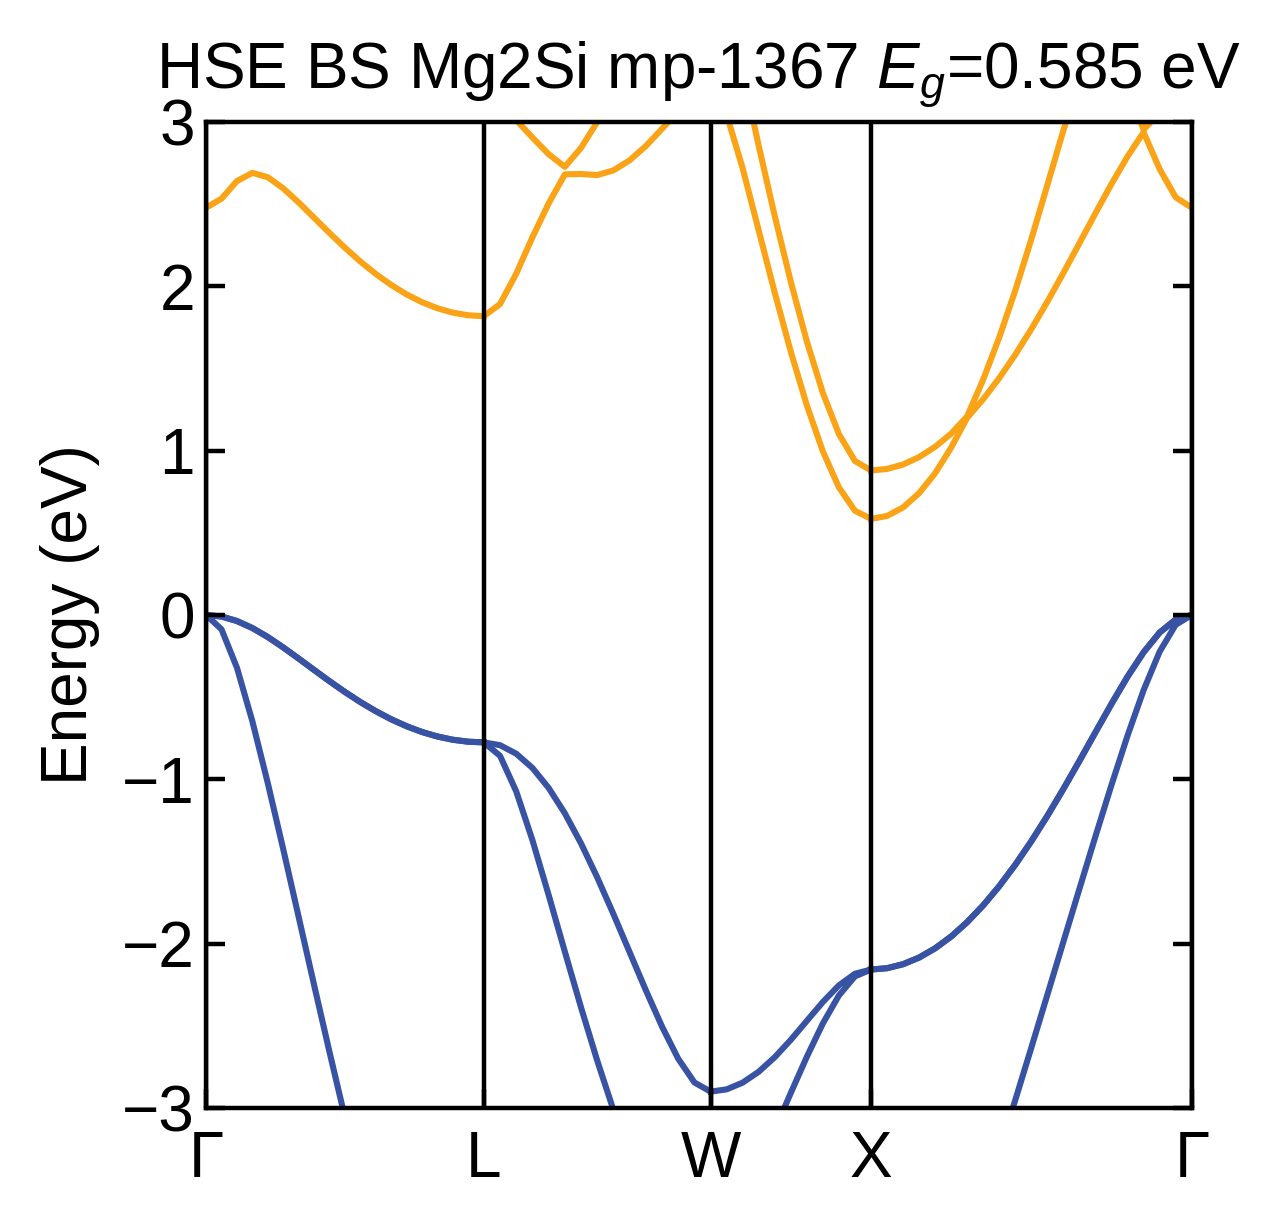

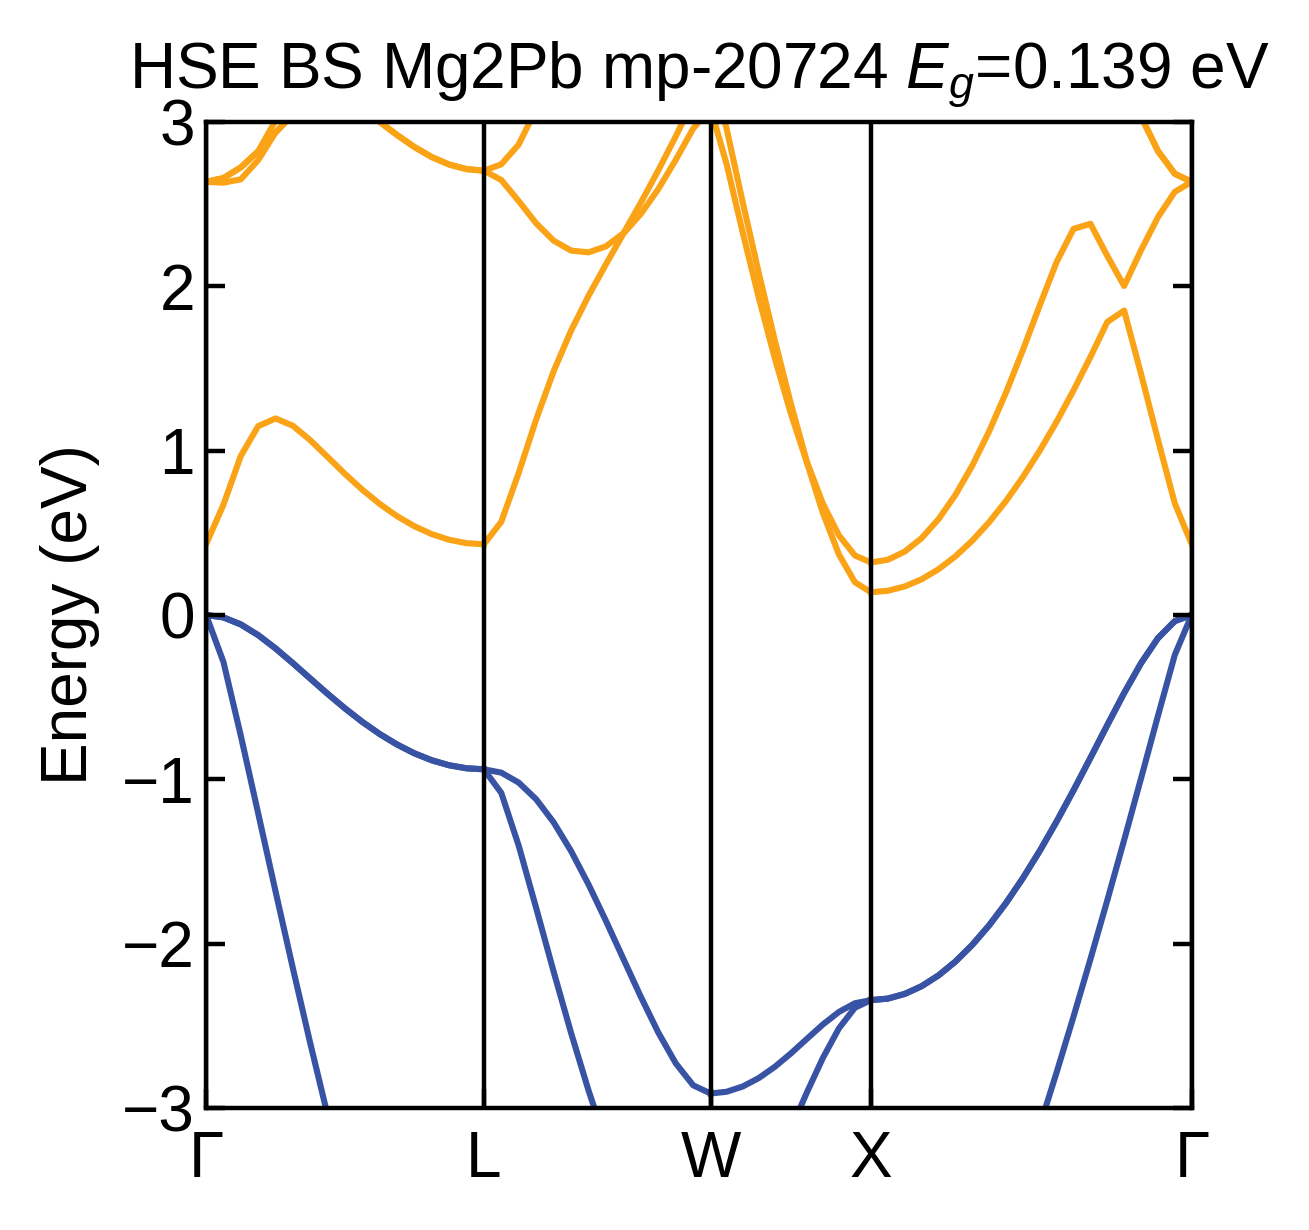

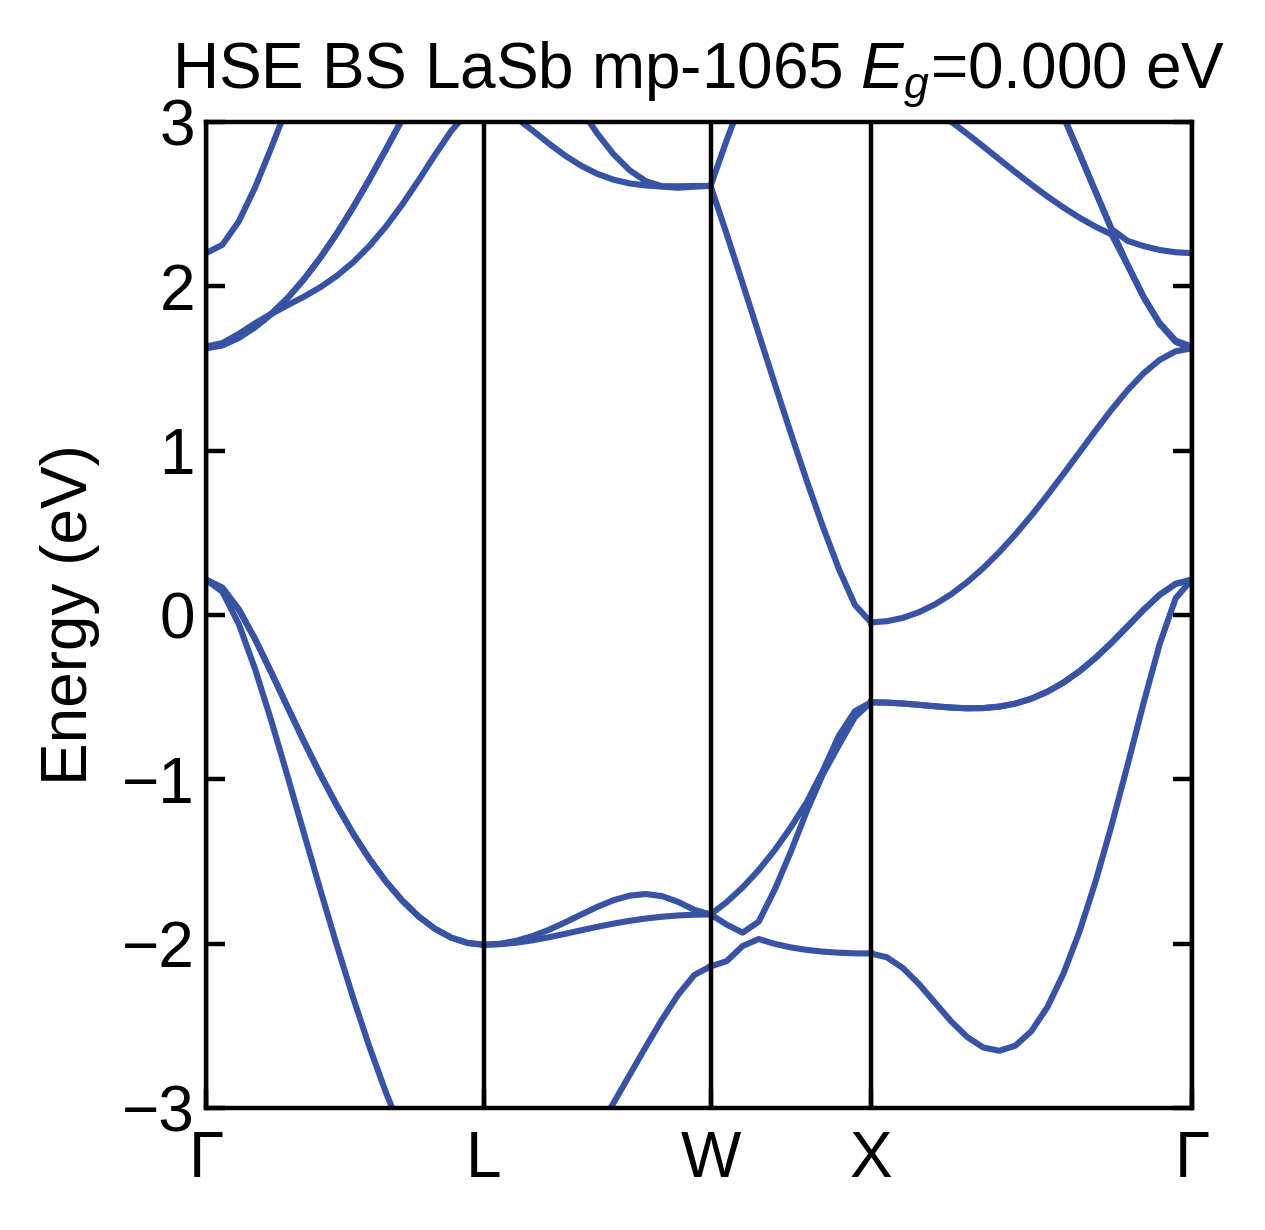

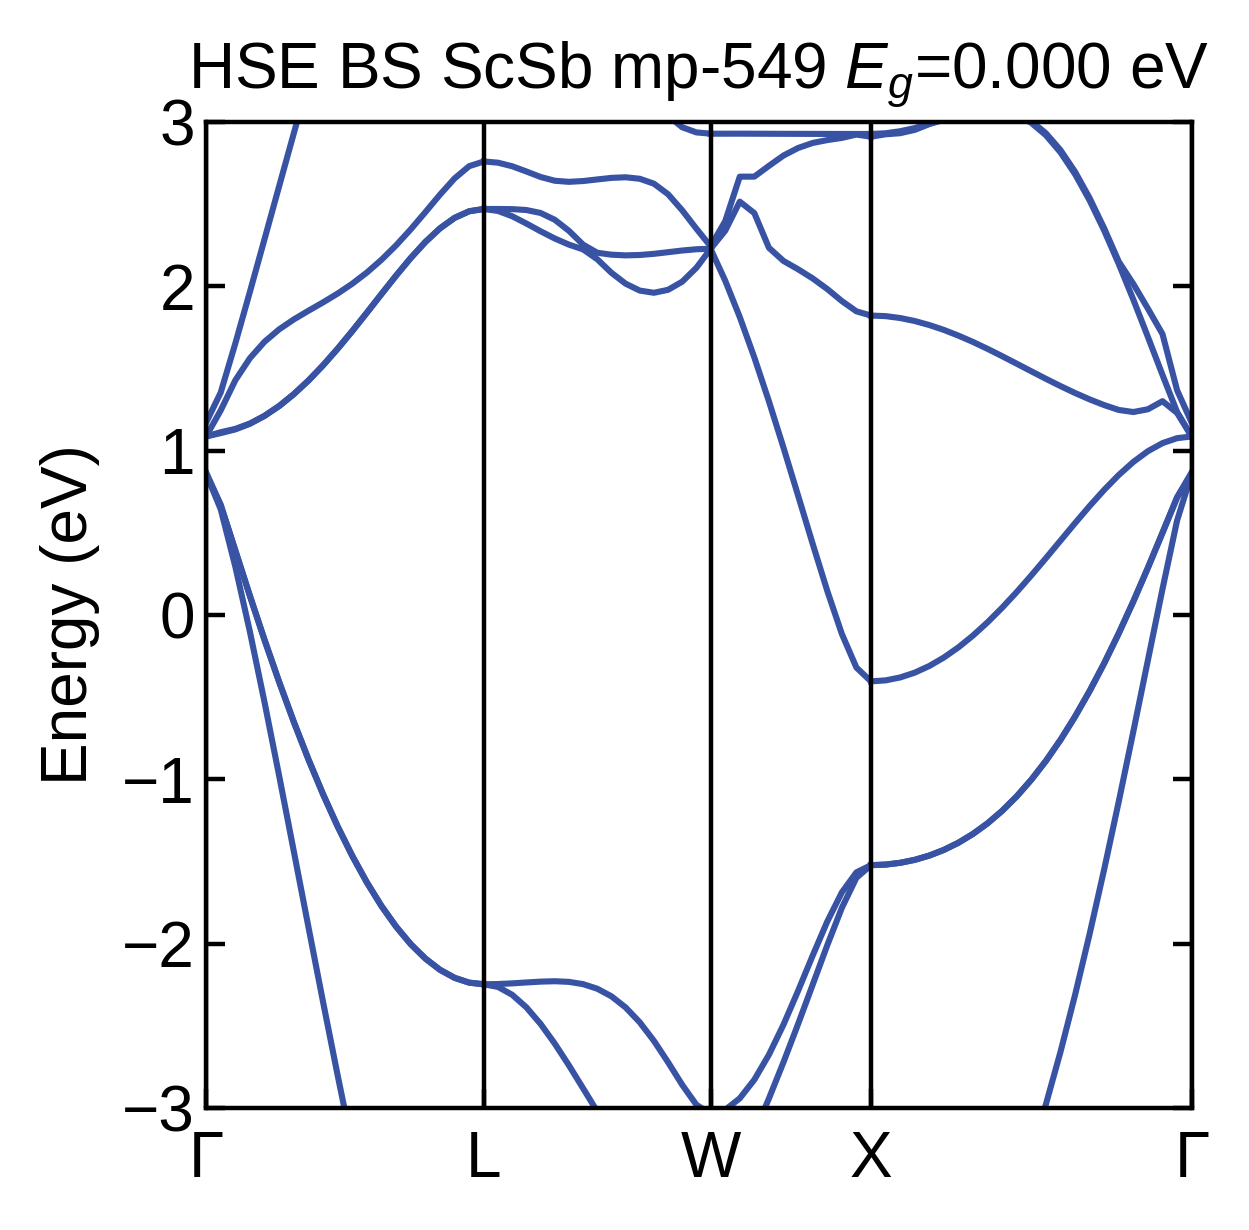

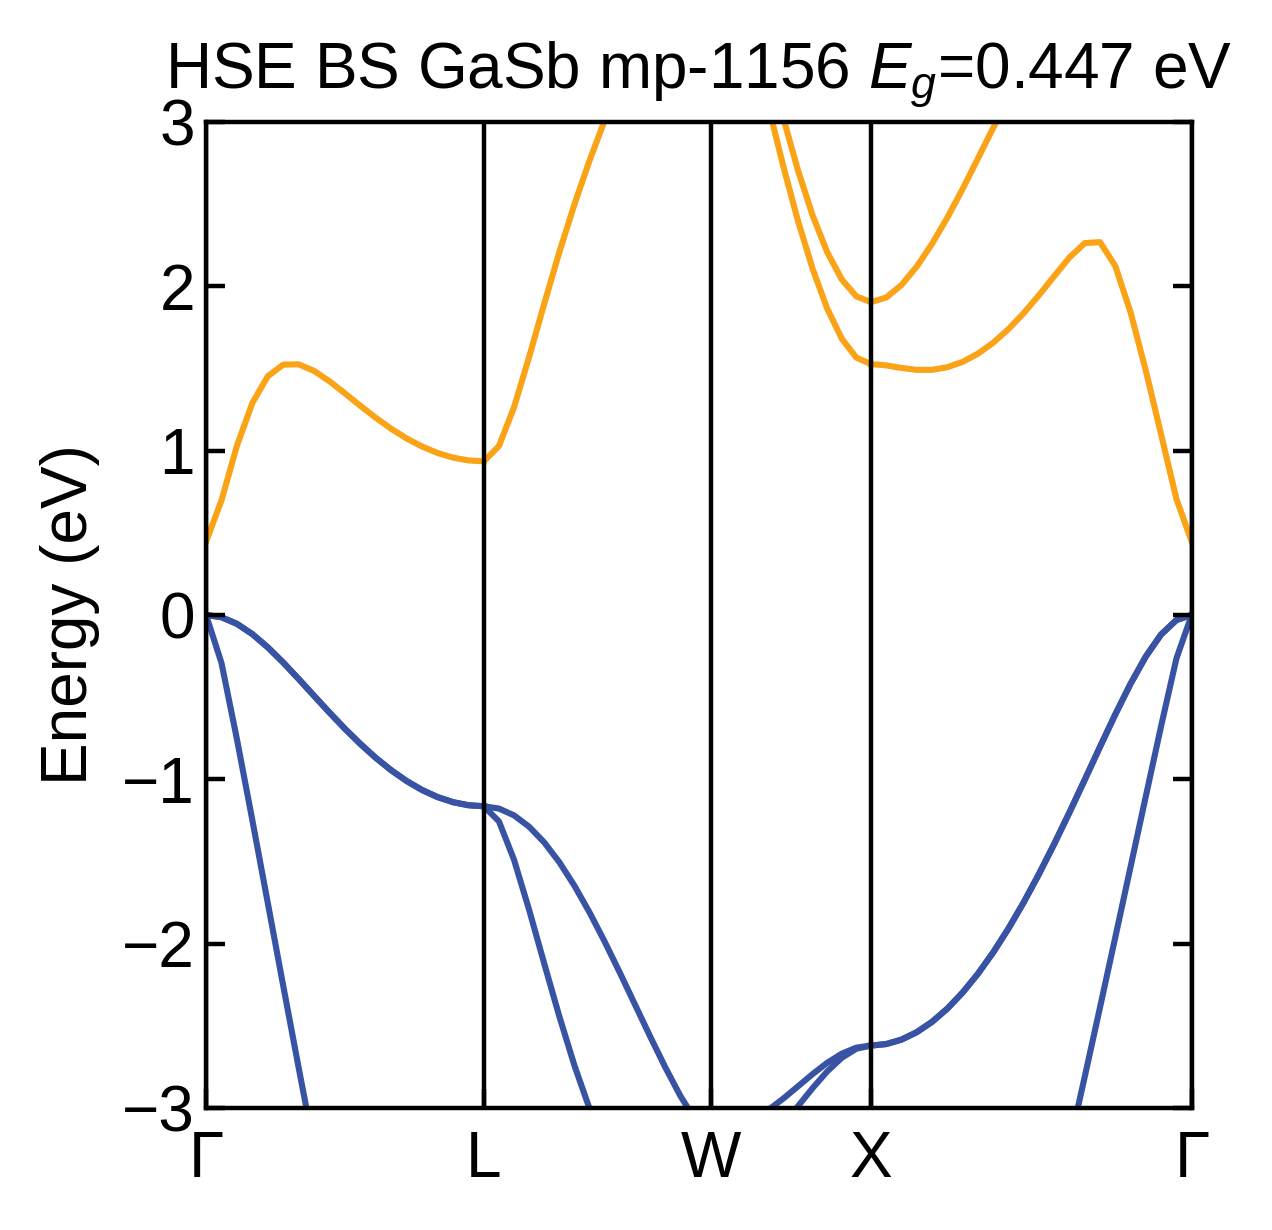

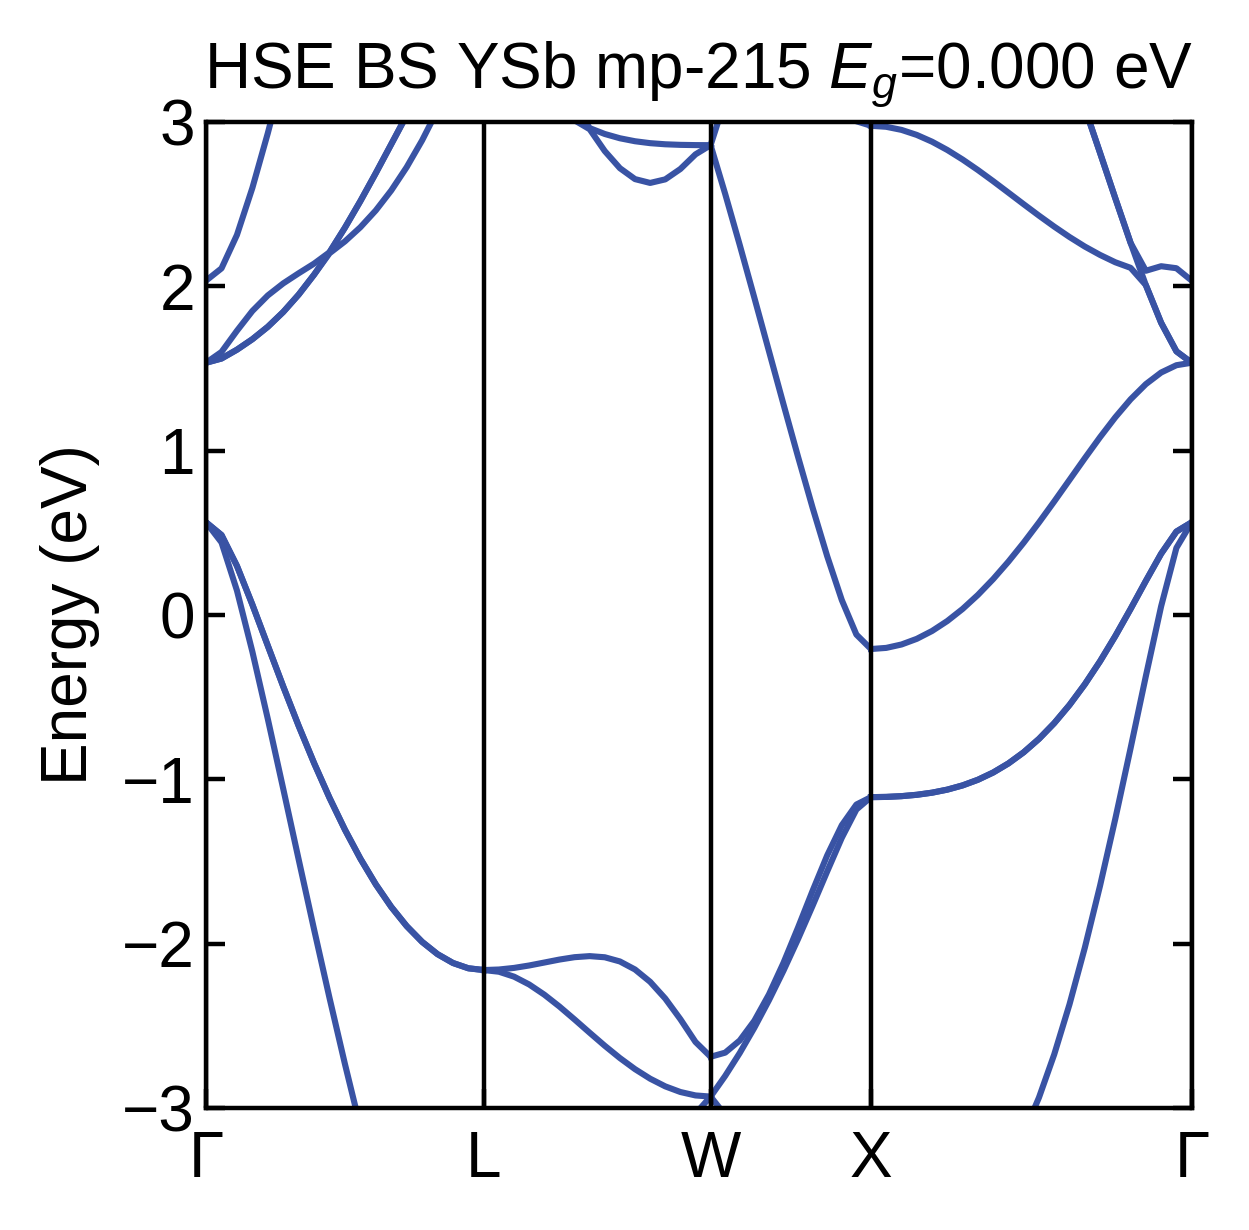

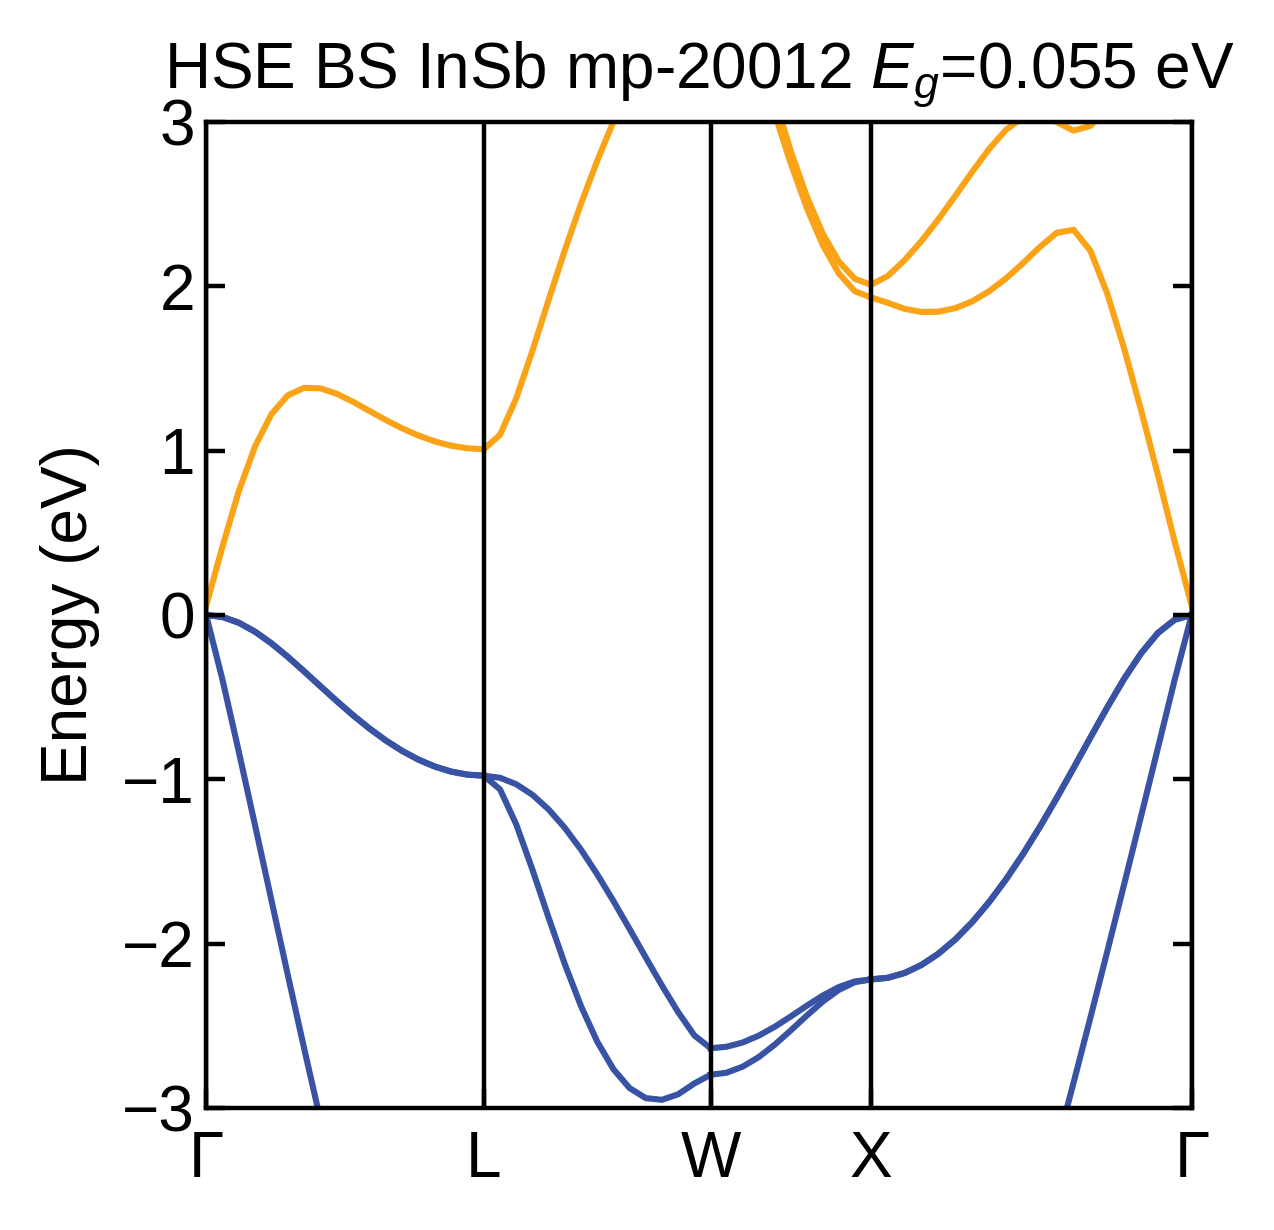

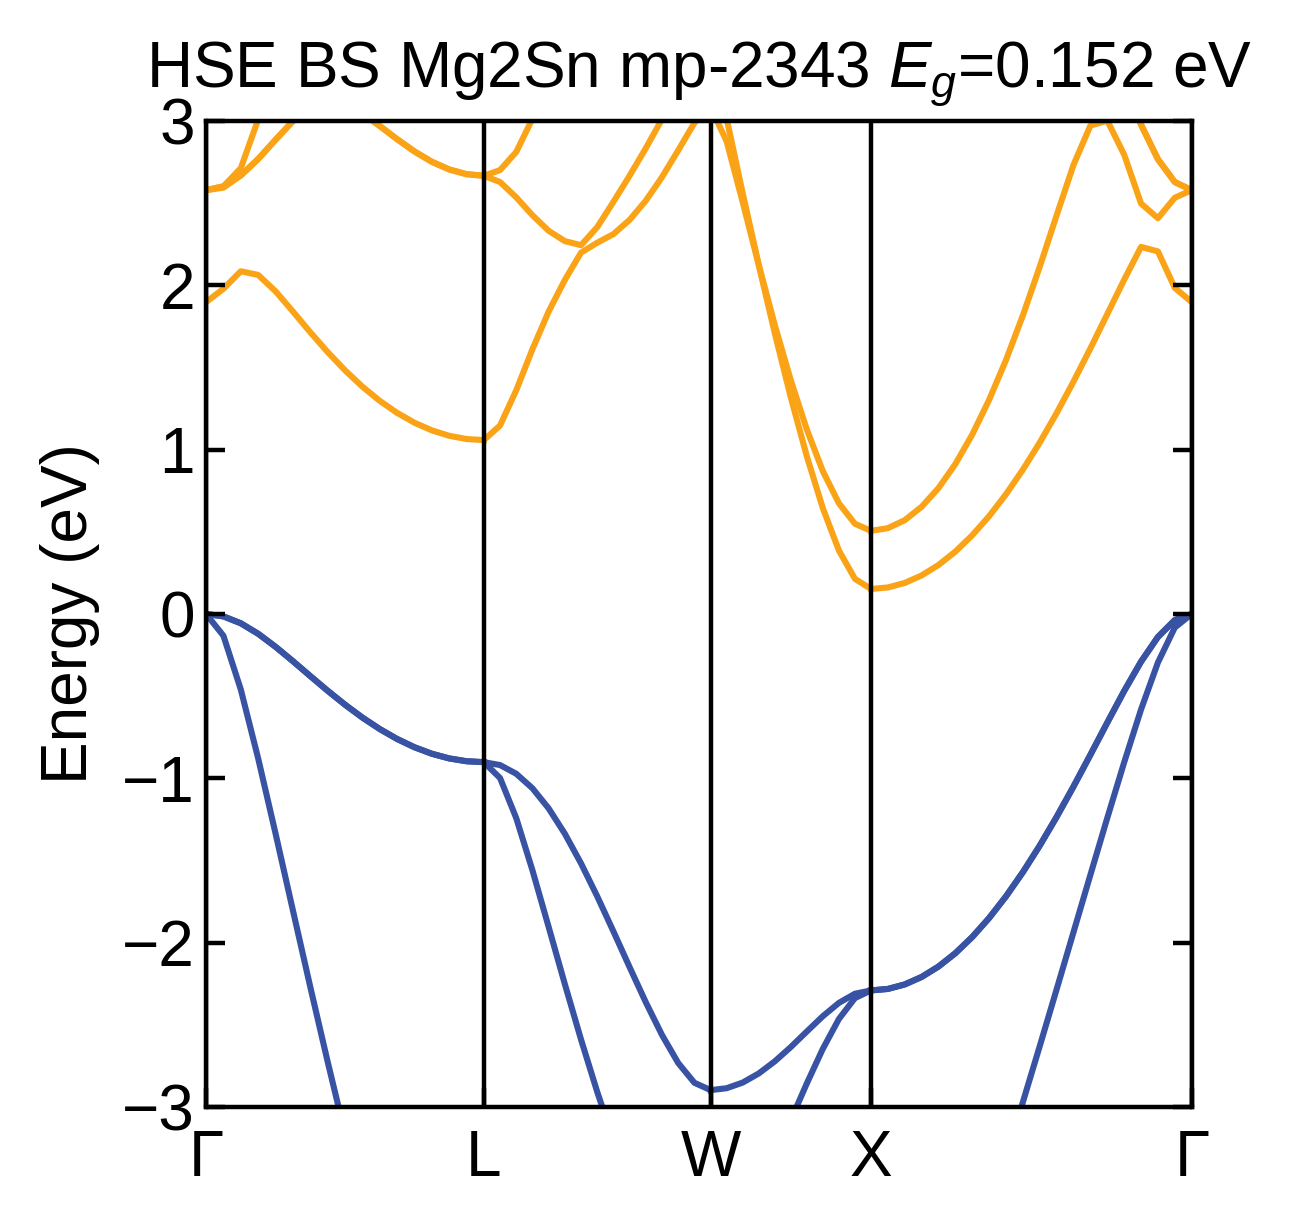

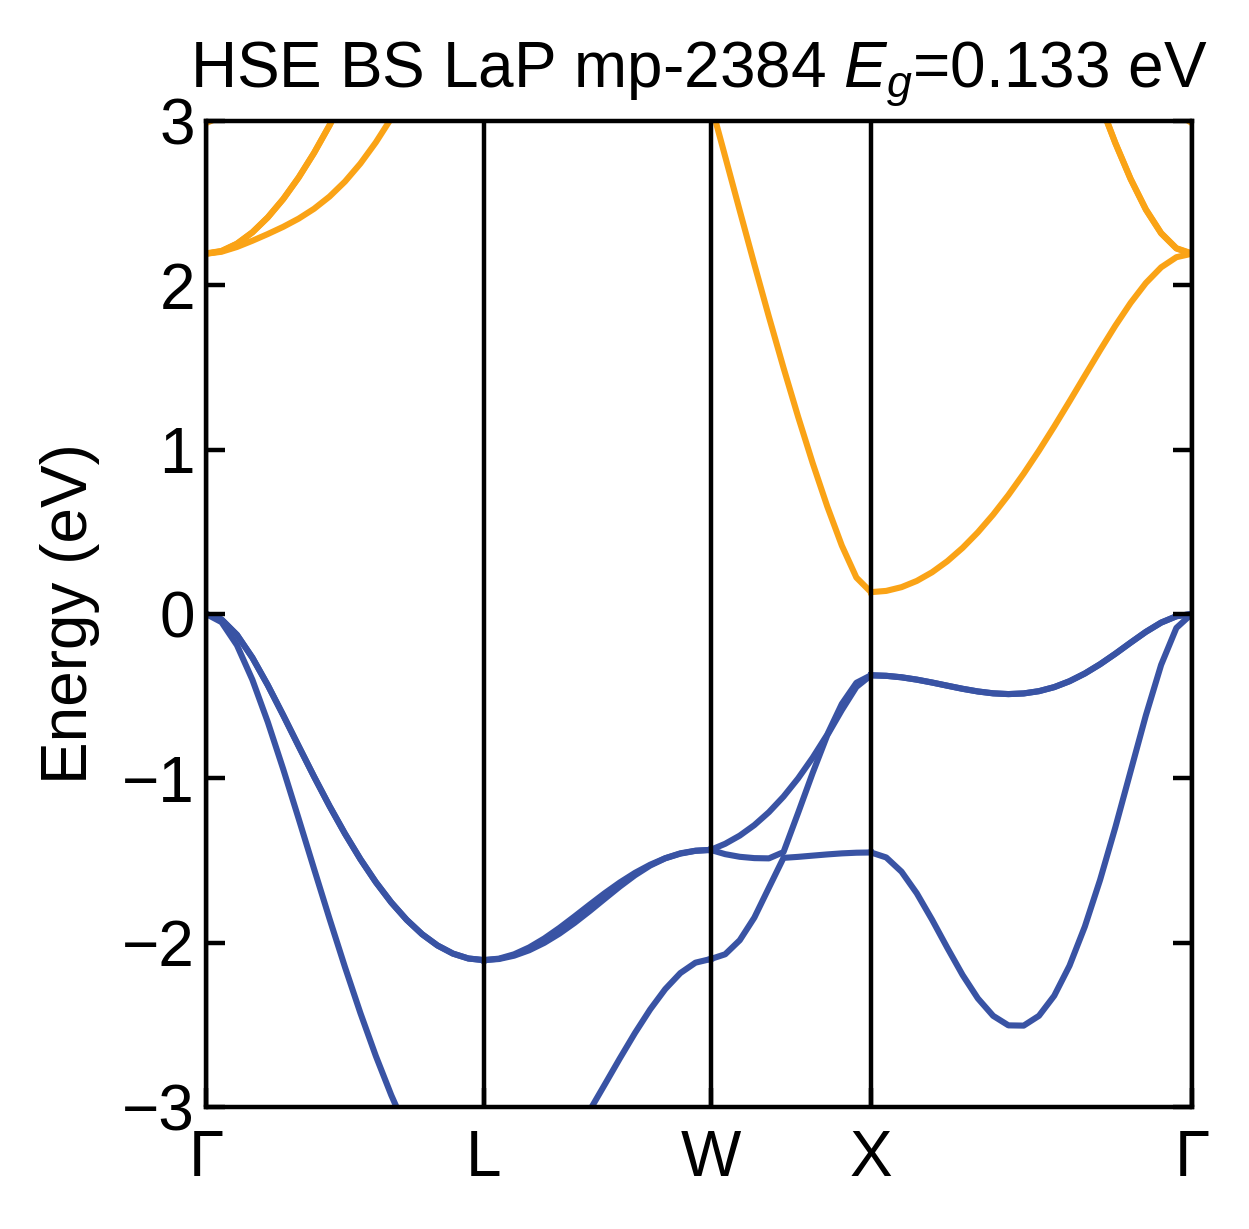

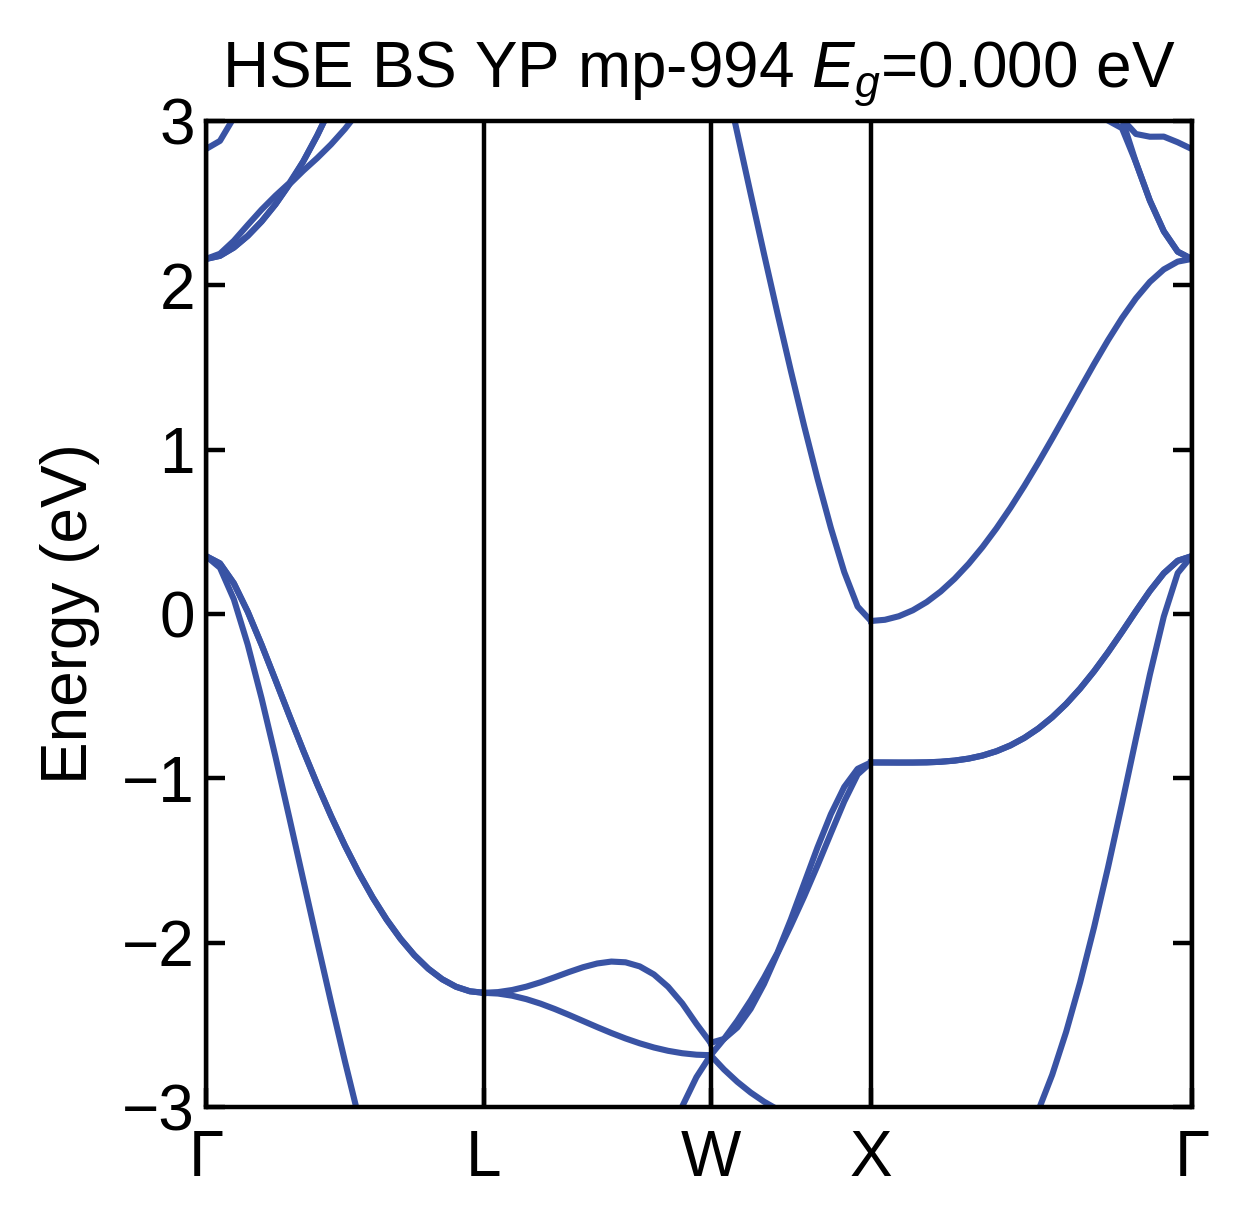

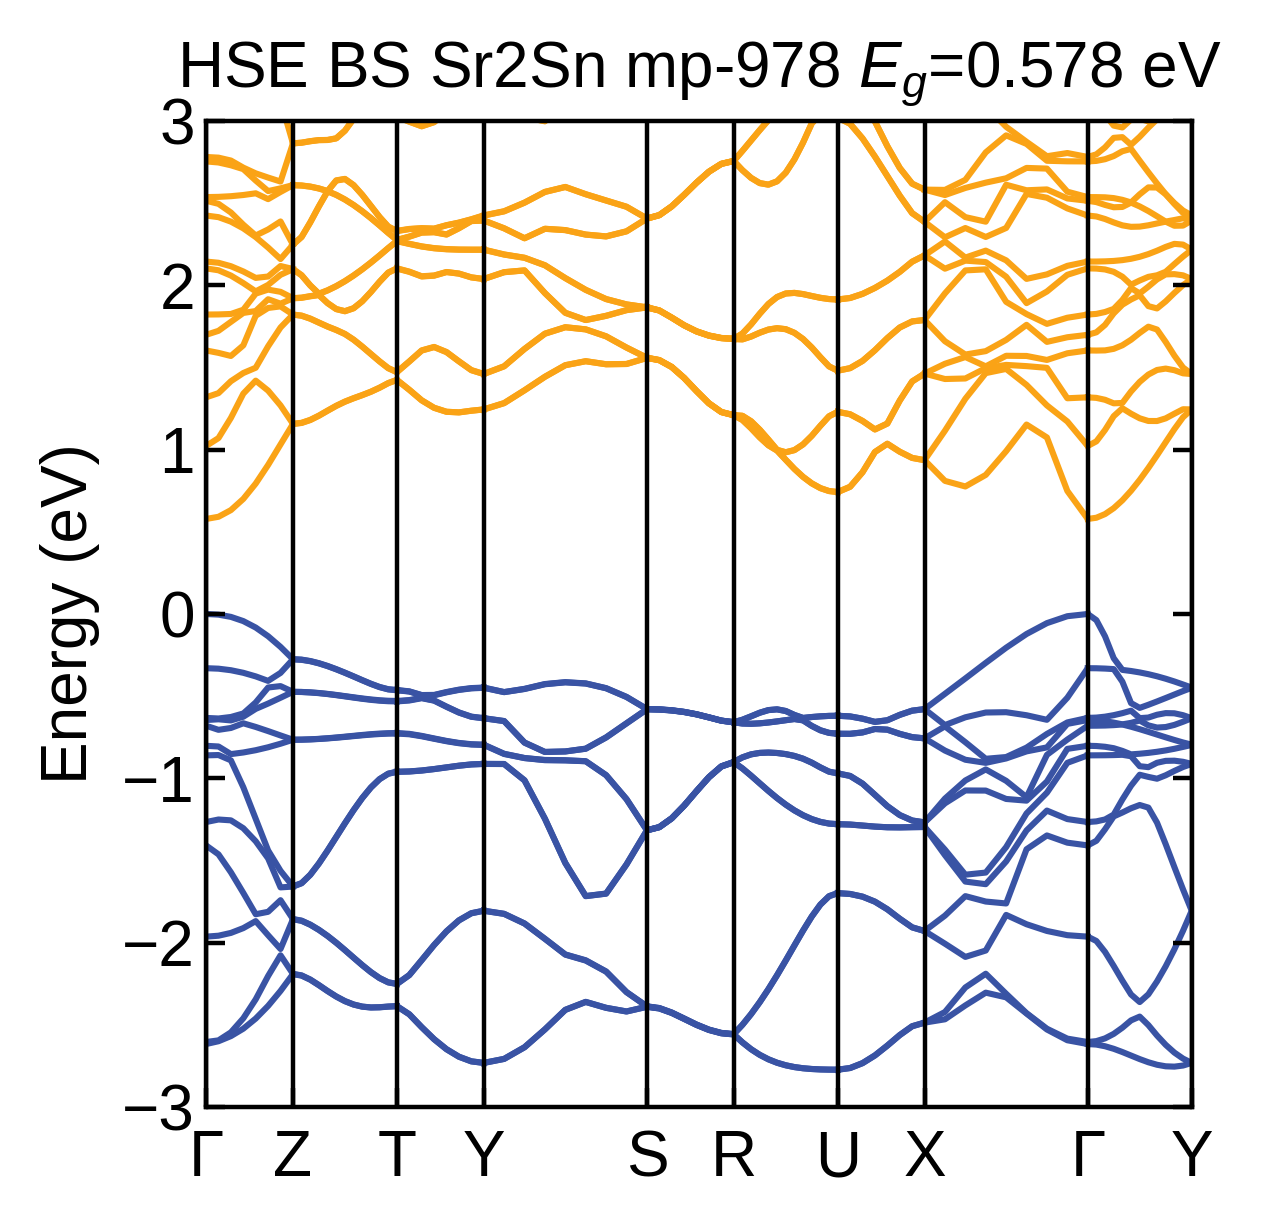

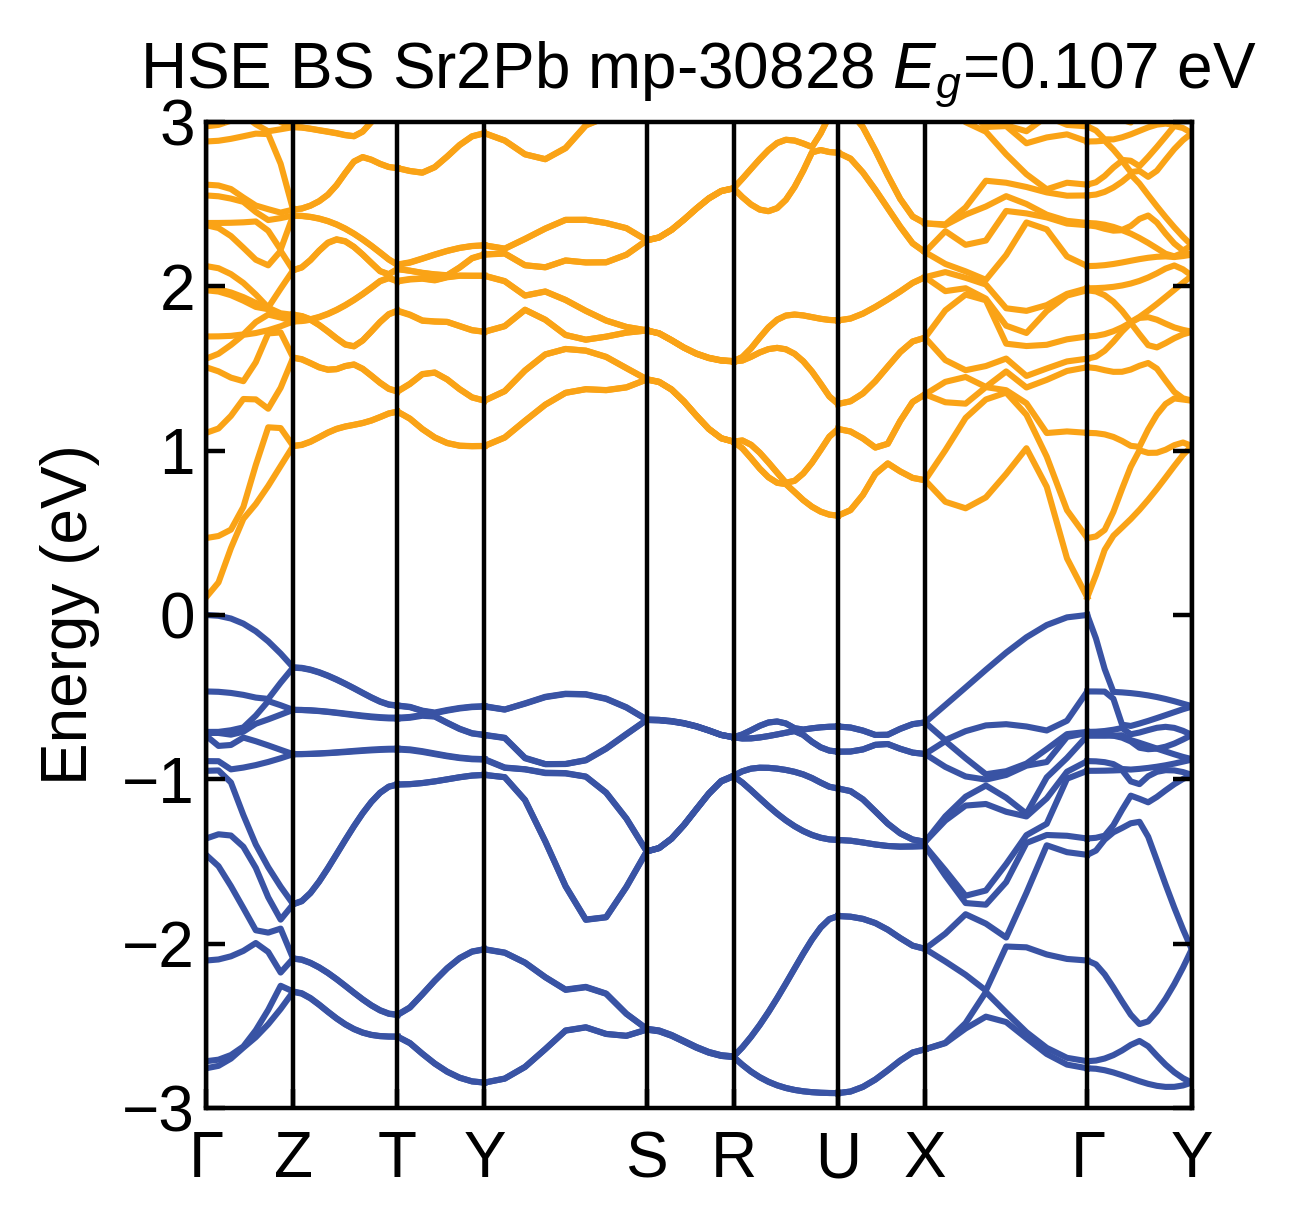

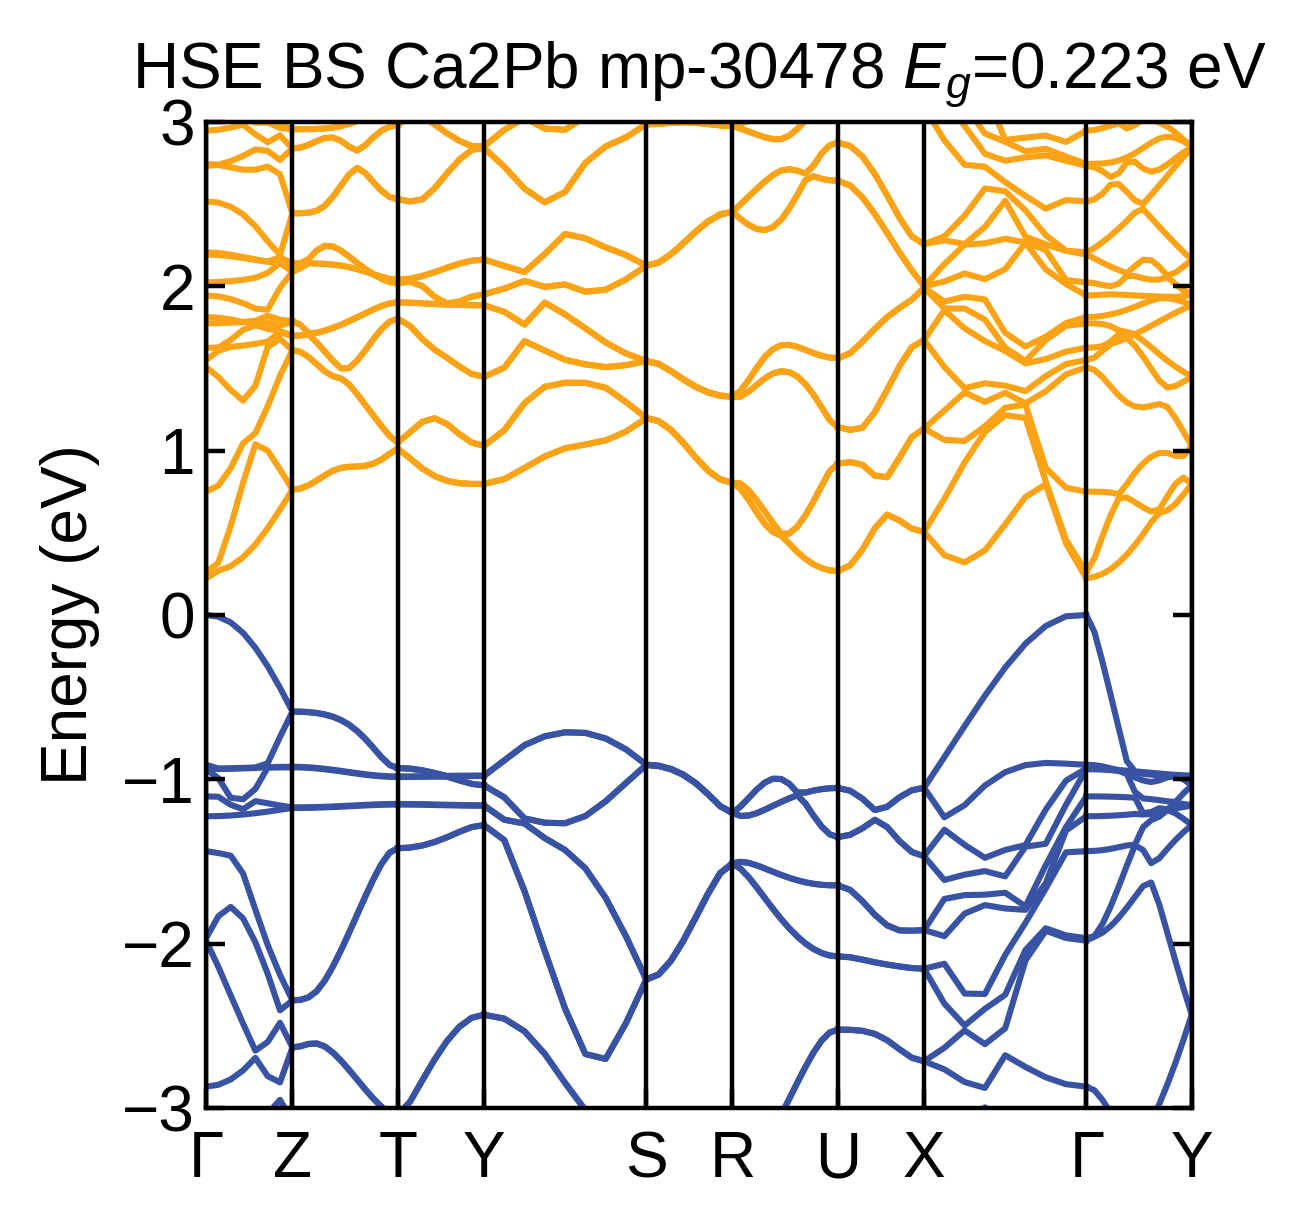

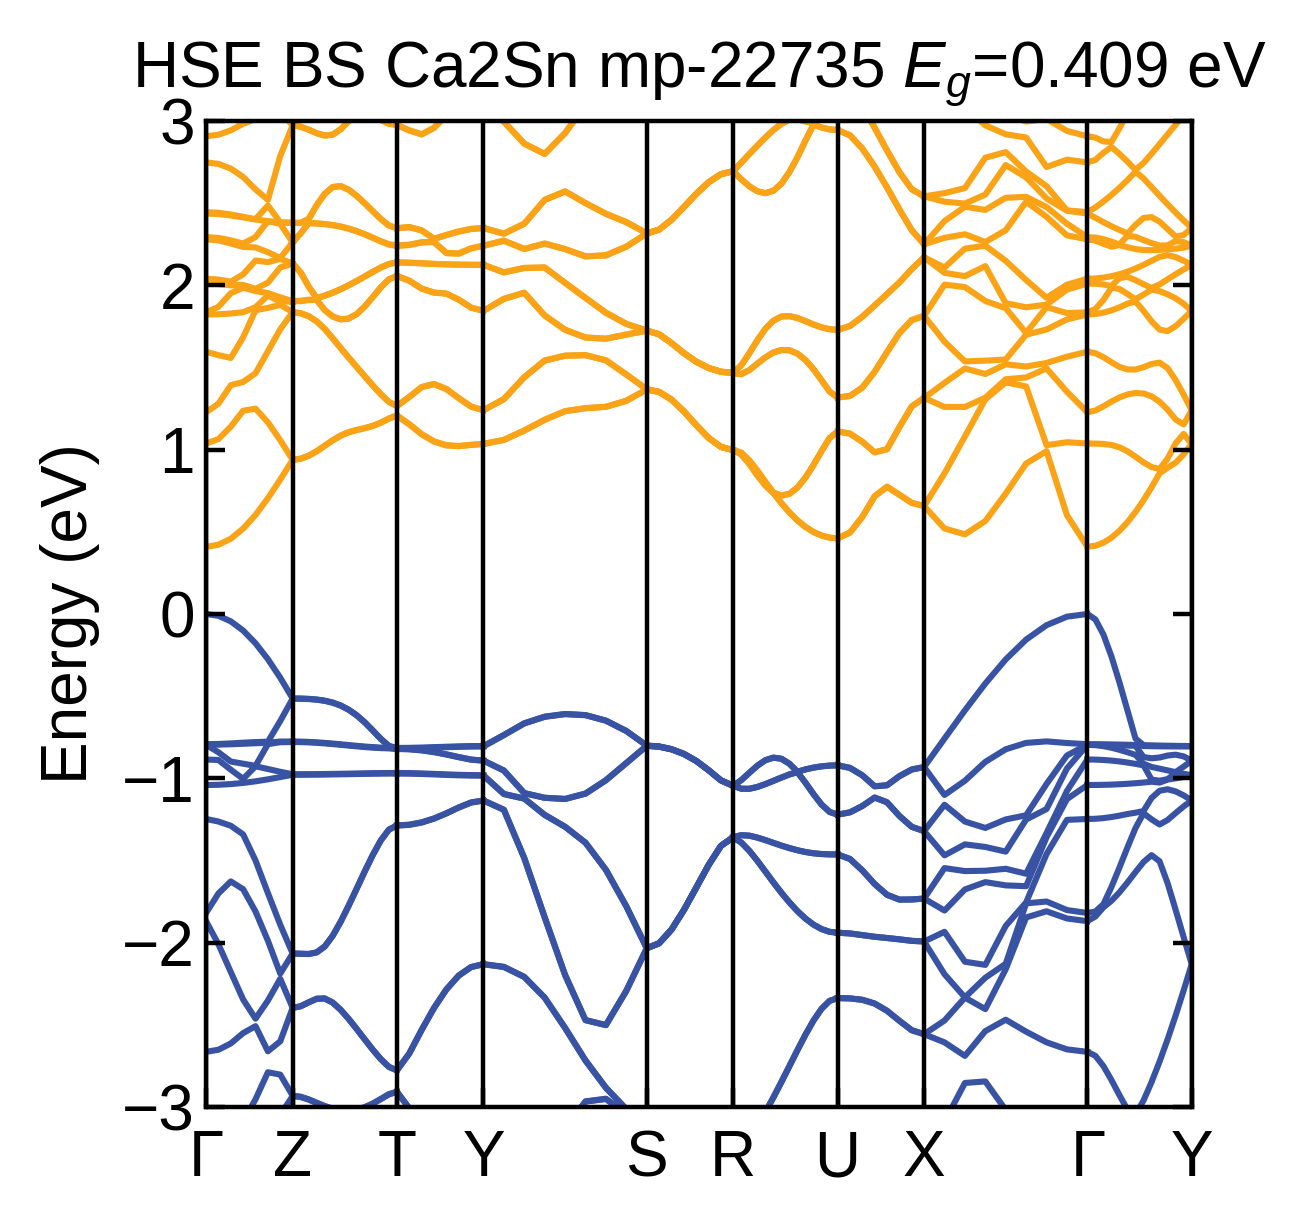

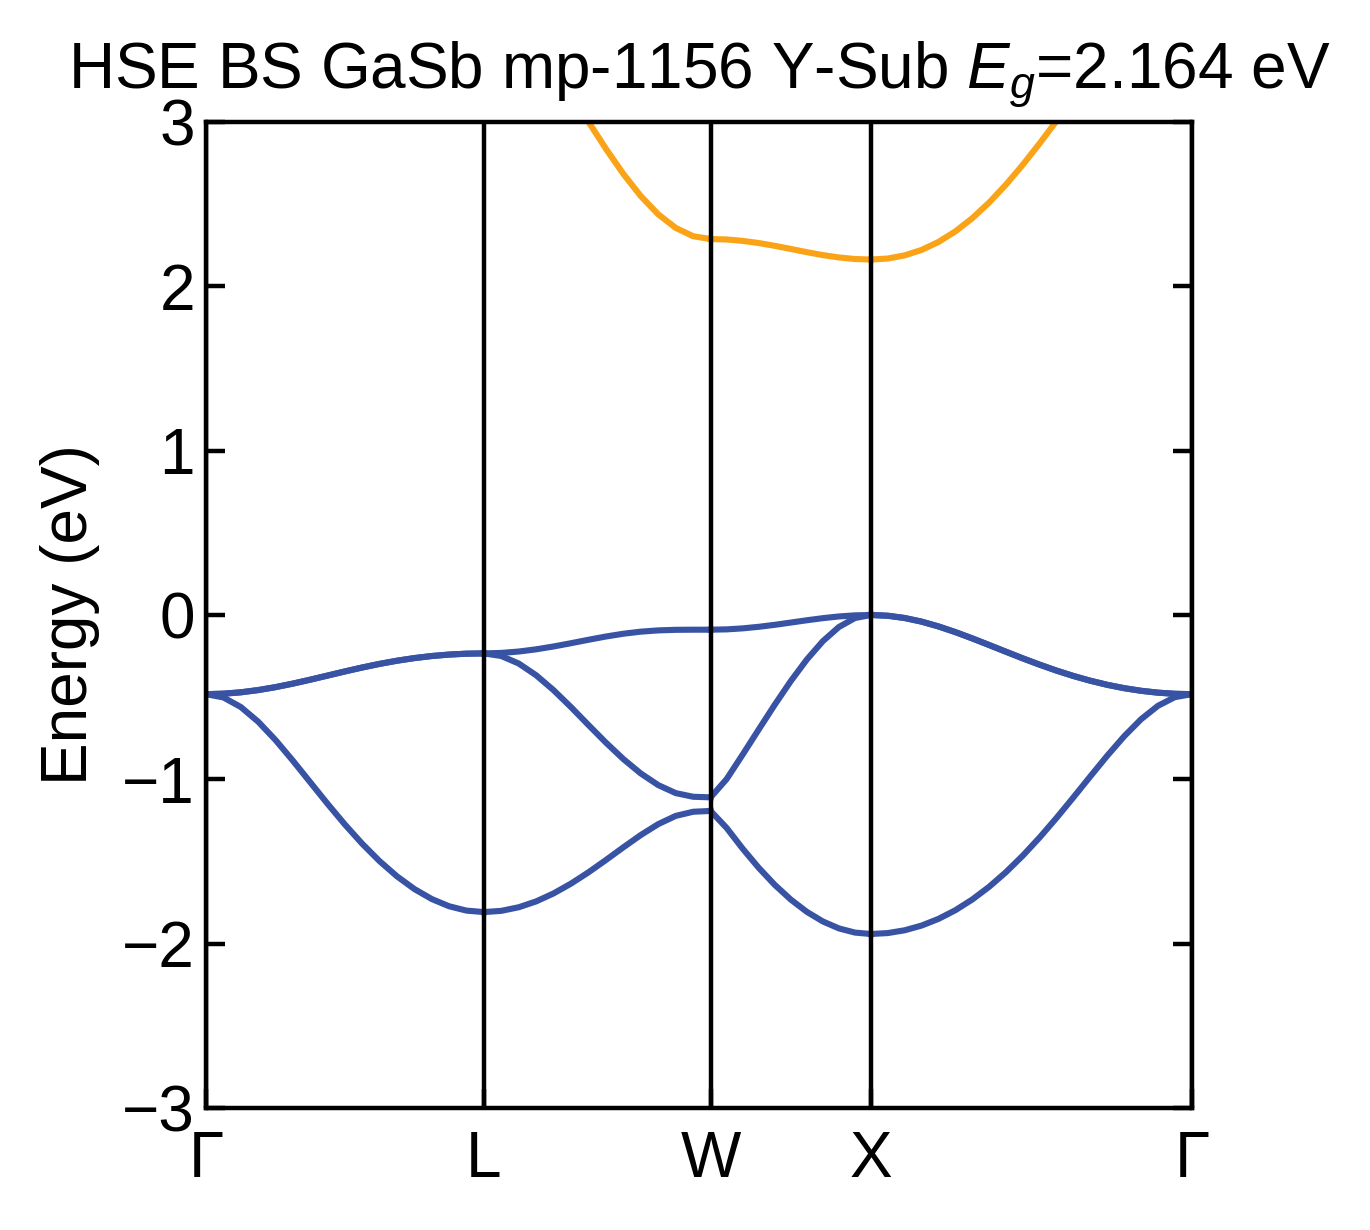

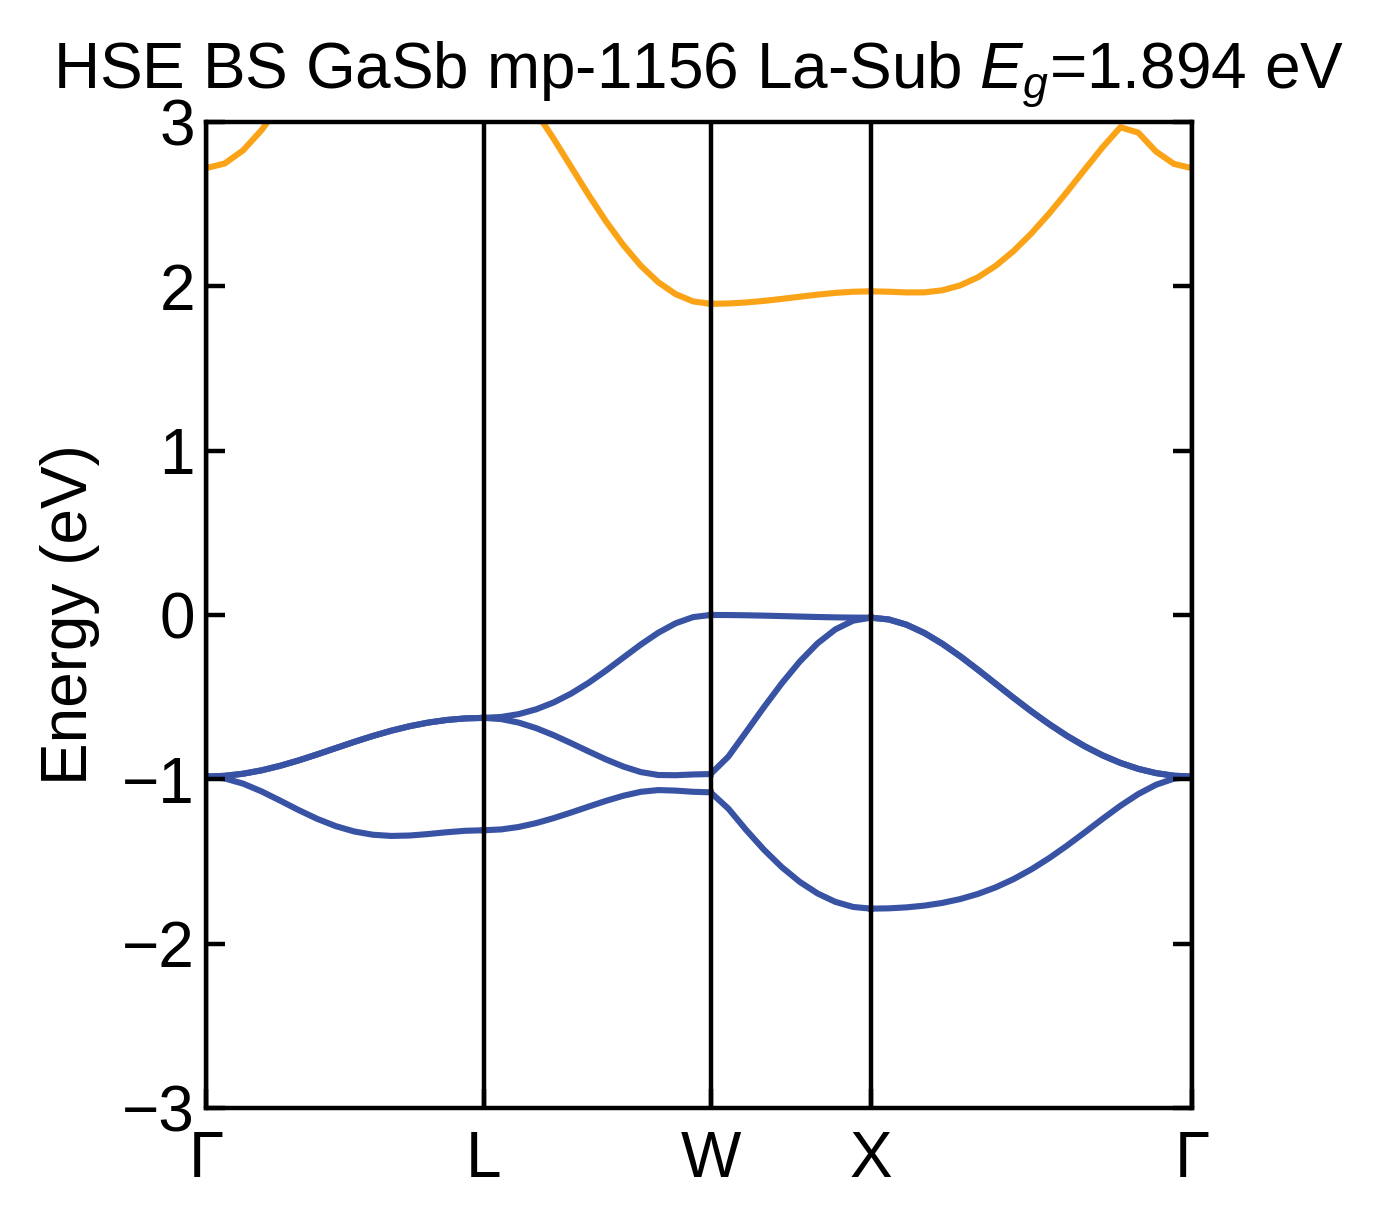

In [18]:
for key, value in results.items():
    fig = value.get_plot(ymin=-3, ymax=3)
    gap = value.bs.get_band_gap()['energy']
    fig.gca().set_title(f'HSE BS {key} $E_g$' + f'={gap:.3f} eV')
    fig.savefig(f'hse_bandstructures/{key}.pdf')